# JOINTS 2026 Main Notebook

Objective: Memprediksi penjualan tiket harian D4-D10 untuk setiap pasangan film dan klaster bioskop berdasarkan penjualan D1-D3 dengan menggunakan MASE sebagai metrik evaluasi.

# Import modules dan libraries

In [1]:
import os, glob, random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor, early_stopping

# Import datasets

In [2]:
_DATA_DIR_CANDIDATES = [
    "../data", "data", "../../data",
    *glob.glob("/kaggle/input/*"), *glob.glob("/kaggle/input/**/", recursive=True),
]
DATA_DIR = next((d for d in _DATA_DIR_CANDIDATES if d and os.path.exists(os.path.join(d, "test_history.csv"))), None)
if DATA_DIR is None:
    raise FileNotFoundError("test_history.csv not found in any candidate DATA_DIR - set it manually.")
print("DATA_DIR =", os.path.abspath(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date_show"])
test_hist = pd.read_csv(f"{DATA_DIR}/test_history.csv", parse_dates=["date_show"])
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["date_show"])
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
holidays = pd.read_csv(f"{DATA_DIR}/holidays.csv", parse_dates=["date"])
prices = pd.read_csv(f"{DATA_DIR}/ticket_prices.csv")

DATA_DIR = c:\MyFolder\Coding\Data Science\Lomba\JOINTS\JOINTS\data


# EDA

### Ringkasan dataset
Ukuran, rentang tanggal, missing value, dan duplikat setiap file.

In [3]:
DATASETS = {"train": train, "test_history": test_hist, "test": test, "sample_sub": sample_sub,
            "movies": movies, "holidays": holidays, "prices": prices}
def describe_file(df):
    dates = df["date_show"] if "date_show" in df else df.get("date")
    return {
        "rows": len(df), "cols": df.shape[1],
        "missing": int(df.isna().sum().sum()), "duplicates": int(df.duplicated().sum()),
        "date_min": dates.min().date() if dates is not None else "-",
        "date_max": dates.max().date() if dates is not None else "-",
    }

pd.DataFrame({name: describe_file(df) for name, df in DATASETS.items()}).T

,rows,cols,missing,duplicates,date_min,date_max
train,138959,7,0,0,2025-04-01,2025-09-30
test_history,32323,7,0,0,2025-10-01,2026-03-20
test,72611,5,0,0,2025-10-04,2026-03-27
sample_sub,72611,2,0,0,-,-
movies,397,7,3,0,-,-
holidays,366,4,348,0,2025-04-01,2026-04-01
prices,207,3,0,0,-,-


In [4]:
train.describe()

,date_show,total_ticket,occupation_rate,total_show
count,138959,138959.000000,138959.000000,138959.000000
mean,2025-07-02 17:12:17.233284352,354.122072,28.331061,7.730921
min,2025-04-01 00:00:00,1.000000,0.000000,1.000000
25%,2025-05-15 00:00:00,69.000000,12.360000,3.000000
50%,2025-07-06 00:00:00,161.000000,21.840000,5.000000
75%,2025-08-18 00:00:00,361.000000,37.010000,8.000000
max,2025-09-30 00:00:00,32845.000000,100.000000,285.000000
std,NaN,725.927987,22.618841,11.005488


### Irisan train dan test
Mengecek berapa banyak film, klaster, dan kota di test yang juga ada di train, karena ini menentukan fitur mana yang bisa dipelajari dari train.

In [5]:
def overlap(col):
    tr, te = set(train[col]), set(test[col])
    return {"train": len(tr), "test": len(te), "overlap": len(tr & te), "test_only": len(te - tr)}

meta_titles = set(movies["original_title"])
all_titles = set(train["movie_title"]) | set(test_hist["movie_title"])
print(pd.DataFrame({c: overlap(c) for c in ["movie_title", "cinema_ids", "city_name"]}).T)
print(f"\nfilm yang ada di movies.csv: {len(all_titles & meta_titles)} / {len(all_titles)}")
print("film test tanpa metadata:", sorted(set(test["movie_title"]) - meta_titles))
print("kota tanpa harga tiket:", sorted((set(train["city_name"]) | set(test_hist["city_name"])) - set(prices["city_name"])))

             train  test  overlap  test_only
movie_title    237   160       10        150
cinema_ids     117   121      117          4
city_name       67    69       67          2

film yang ada di movies.csv: 339 / 390
film test tanpa metadata: ['AVATAR: FIRE AND ASH (3D)', 'AVATAR: FIRE AND ASH (IMAX 3D)', 'BLADES OF THE GUARDIANS (IMAX 2D)', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)', 'HOPPERS (3D)', 'HOPPERS (IMAX 2D)', 'MERCY (IMAX 2D)', 'PREDATOR: BADLANDS (3D)', 'PREDATOR: BADLANDS (IMAX 2D)', 'SCREAM 7 (IMAX 2D)', 'STRAY KIDS: THE DOMINATE EXPERIENCE (IMAX 2D)', 'THE BRIDE! (IMAX 2D)', 'THE RUNNING MAN (IMAX 2D)', 'TRON: ARES (3D)', 'TRON: ARES (IMAX 2D)', 'WICKED: FOR GOOD (3D)', 'WICKED: FOR GOOD (IMAX 2D)', 'WUTHERING HEIGHTS (IMAX 2D)', 'ZOOTOPIA 2 (IMAX 2D)']
kota tanpa harga tiket: []


### Format film
Beberapa judul adalah versi format lain dari film yang sama (3D, IMAX), dan judul ini tidak ada di movies.csv sehingga metadatanya harus diambil dari judul dasarnya.

In [6]:
FORMAT_PATTERN = r"\s*\((?:IMAX )?[23]D\)\s*$"
formats = pd.DataFrame({
    name: df.drop_duplicates("movie_title")["movie_title"].str.extract(r"\(((?:IMAX )?[23]D)\)\s*$")[0].fillna("regular").value_counts()
    for name, df in {"train": train, "test": test}.items()
}).fillna(0).astype(int)
base_titles = pd.Series(sorted(all_titles)).str.replace(FORMAT_PATTERN, "", regex=True)
print(formats)
print(f"\nfilm dengan metadata setelah judul format dihapus: {base_titles.isin(meta_titles).sum()} / {len(base_titles)}")
print("masih tanpa metadata:", sorted(set(base_titles[~base_titles.isin(meta_titles)]))[:20])

         train  test
0                   
3D           8     5
IMAX 2D     20    14
IMAX 3D      0     1
regular    209   140

film dengan metadata setelah judul format dihapus: 390 / 390
masih tanpa metadata: []


### Distribusi tiket harian
Sebaran total_ticket dilihat dalam skala log karena nilainya sangat timpang antar film dan klaster.

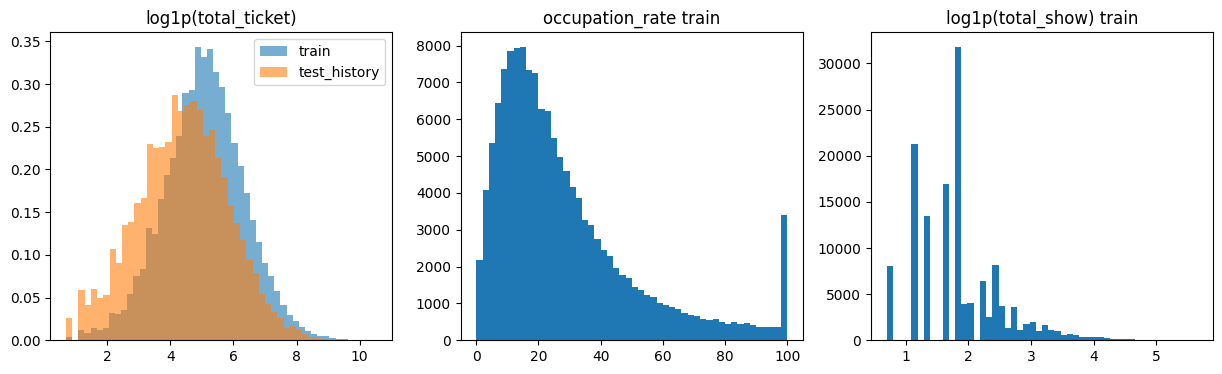

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(np.log1p(train["total_ticket"]), bins=50, alpha=0.6, density=True, label="train")
ax[0].hist(np.log1p(test_hist["total_ticket"]), bins=50, alpha=0.6, density=True, label="test_history")
ax[0].set_title("log1p(total_ticket)")
ax[0].legend()
ax[1].hist(train["occupation_rate"], bins=50)
ax[1].set_title("occupation_rate train")
ax[2].hist(np.log1p(train["total_show"]), bins=50)
ax[2].set_title("log1p(total_show) train")
plt.show()

### Tiket nasional per hari
Total tiket semua film per tanggal untuk train dan test_history, dengan tanggal libur ditandai garis merah, untuk melihat musim ramai dan efek libur.

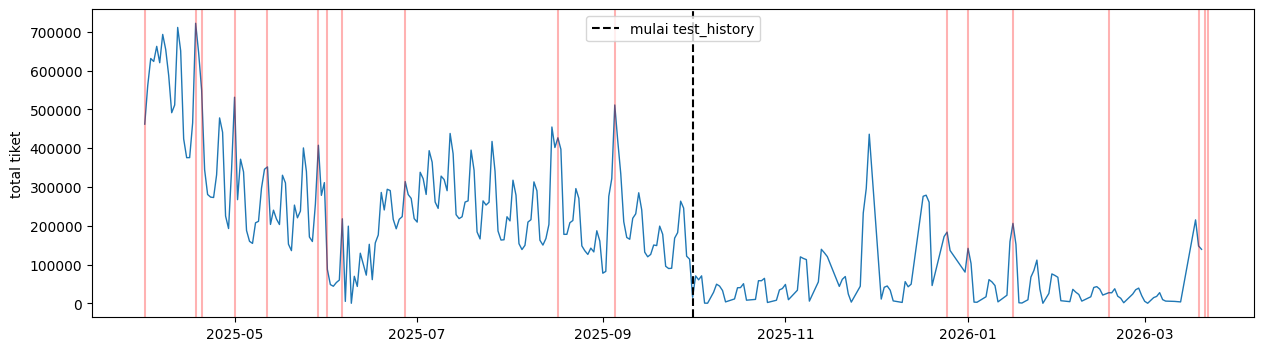

In [8]:
daily = pd.concat([train, test_hist]).groupby("date_show")["total_ticket"].sum()
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily.index, daily.values, lw=1)
for d in holidays.loc[holidays["holiday_tipe"] == "holiday", "date"]:
    ax.axvline(d, color="red", alpha=0.3)
ax.axvline(test_hist["date_show"].min(), color="black", ls="--", label="mulai test_history")
ax.set_ylabel("total tiket")
ax.legend()
plt.show()

### Efek hari dan libur
Rata-rata tiket per film-klaster-hari berdasarkan hari dalam minggu dan tipe hari.

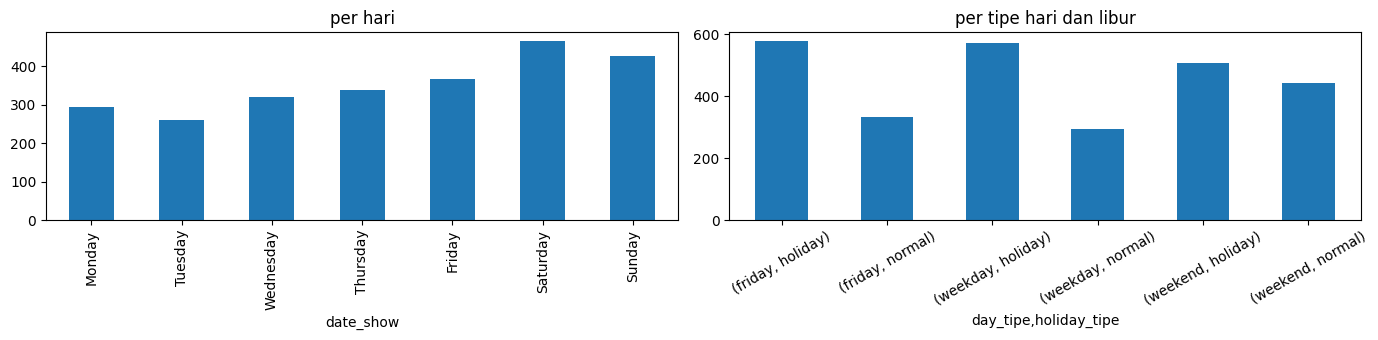

,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
17,2025-04-18,friday,holiday,Wafat Yesus Kristus
19,2025-04-20,weekend,holiday,Kebangkitan Yesus Kristus (Paskah)
30,2025-05-01,weekday,holiday,Hari Buruh Internasional
41,2025-05-12,weekday,holiday,Hari Raya Waisak 2569 BE
58,2025-05-29,weekday,holiday,Kenaikan Yesus Kristus
61,2025-06-01,weekend,holiday,Hari Lahir Pancasila
66,2025-06-06,friday,holiday,Idul Adha 1446 H
87,2025-06-27,friday,holiday,1 Muharam Tahun Baru Islam 1447 H
138,2025-08-17,weekend,holiday,Proklamasi Kemerdekaan Republik Indonesia


In [9]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
cal = train.merge(holidays.rename(columns={"date": "date_show"}), on="date_show", how="left")
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
cal.groupby(cal["date_show"].dt.day_name())["total_ticket"].mean().reindex(DAY_ORDER).plot(kind="bar", ax=ax[0], title="per hari")
cal.groupby(["day_tipe", "holiday_tipe"])["total_ticket"].mean().plot(kind="bar", ax=ax[1], title="per tipe hari dan libur", rot=30)
plt.tight_layout()
plt.show()
holidays[holidays["holiday_tipe"] == "holiday"]

### Jumlah klaster per hari untuk tiap film
Film biasanya punya beberapa hari preview di sedikit klaster sebelum tayang luas, pola ini dipakai untuk menentukan D1 pada train.

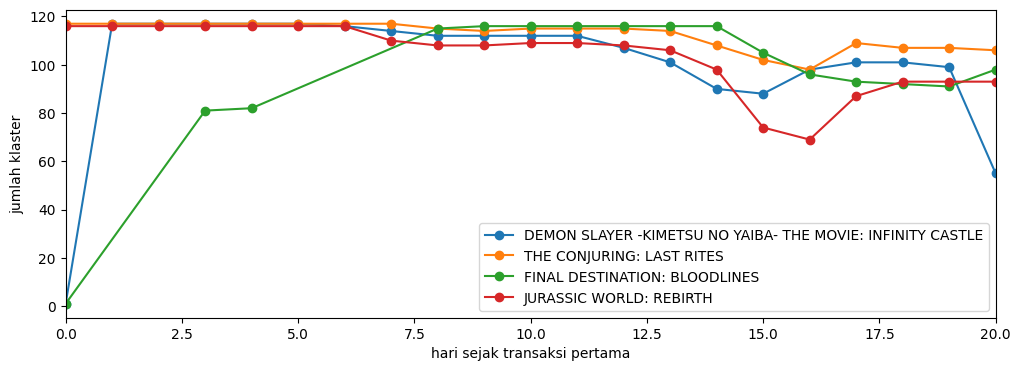

In [10]:
clusters_per_day = train.groupby(["movie_title", "date_show"])["cinema_ids"].nunique()
first_date = train.groupby("movie_title")["date_show"].min()
max_clusters = clusters_per_day.groupby(level=0).max()
examples = max_clusters[first_date > first_date.min()].nlargest(4).index

fig, ax = plt.subplots(figsize=(12, 4))
for title in examples:
    s = clusters_per_day[title]
    ax.plot((s.index - s.index.min()).days, s.values, marker="o", label=title)
ax.set_xlim(0, 20)
ax.set_xlabel("hari sejak transaksi pertama")
ax.set_ylabel("jumlah klaster")
ax.legend()
plt.show()

### Kurva penurunan D1-D10
Rasio tiket setiap hari terhadap rata-rata D1-D3 pasangan (skala MASE), dengan D1 train = hari pertama film tayang di minimal 50% klaster maksimalnya. Ini adalah bentuk target yang harus ditebak model.

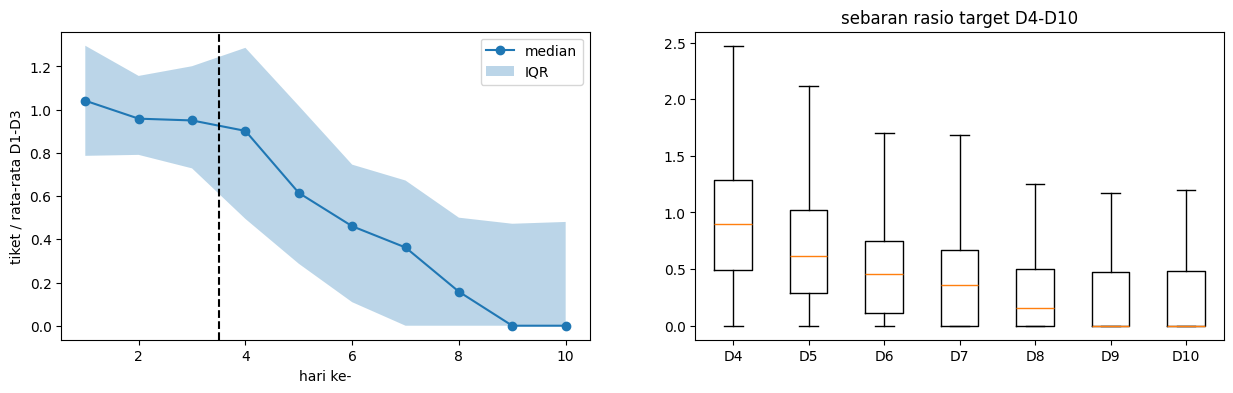

film: 205 | pasangan: 8007
porsi target nol per horizon:
 {4: 0.109, 5: 0.145, 6: 0.22, 7: 0.294, 8: 0.436, 9: 0.511, 10: 0.556}


In [11]:
eda_d1 = (
    clusters_per_day[clusters_per_day >= 0.5 * clusters_per_day.groupby(level=0).transform("max")]
    .reset_index().groupby("movie_title")["date_show"].min()
)
eda_d1 = eda_d1[(first_date[eda_d1.index] > train["date_show"].min())
                & (eda_d1 + pd.Timedelta(days=9) <= train["date_show"].max())]

curve = train[train["movie_title"].isin(eda_d1.index)].copy()
curve["day"] = (curve["date_show"] - curve["movie_title"].map(eda_d1)).dt.days + 1
curve = curve[curve["day"].between(1, 10)].pivot_table(
    index=["movie_title", "cinema_ids"], columns="day", values="total_ticket", fill_value=0
).reindex(columns=range(1, 11), fill_value=0)
curve = curve[curve[3] > 0]
ratio = curve.div(curve[[1, 2, 3]].mean(axis=1), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(ratio.columns, ratio.median(), marker="o", label="median")
ax[0].fill_between(ratio.columns, ratio.quantile(0.25), ratio.quantile(0.75), alpha=0.3, label="IQR")
ax[0].axvline(3.5, color="black", ls="--")
ax[0].set_xlabel("hari ke-")
ax[0].set_ylabel("tiket / rata-rata D1-D3")
ax[0].legend()
ax[1].boxplot([ratio[d].clip(upper=3) for d in range(4, 11)], tick_labels=[f"D{d}" for d in range(4, 11)], showfliers=False)
ax[1].set_title("sebaran rasio target D4-D10")
plt.show()
print(f"film: {len(eda_d1)} | pasangan: {len(ratio)}")
print("porsi target nol per horizon:\n", (curve[list(range(4, 11))] == 0).mean().round(3).to_dict())

### Pengaruh hari D1 pada kurva
Kurva median dikelompokkan berdasarkan hari D1, karena posisi akhir pekan di dalam D1-D10 menggeser pola naik turun. Hari D1 dengan kurang dari 30 pasangan tidak ditampilkan karena terlalu sedikit.

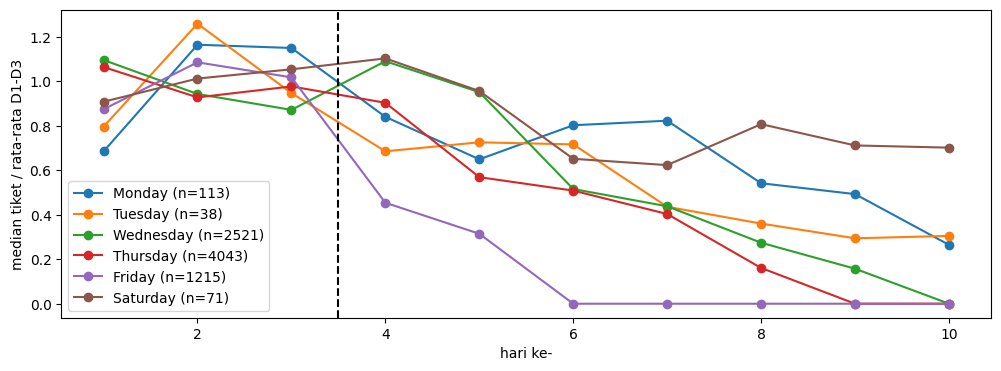

In [12]:
d1_dow = ratio.index.get_level_values("movie_title").map(eda_d1).dayofweek
fig, ax = plt.subplots(figsize=(12, 4))
for dow, grp in ratio.groupby(d1_dow):
    if len(grp) < 30:
        continue
    ax.plot(grp.columns, grp.median(), marker="o", label=f"{DAY_ORDER[dow]} (n={len(grp)})")
ax.axvline(3.5, color="black", ls="--")
ax.set_xlabel("hari ke-")
ax.set_ylabel("median tiket / rata-rata D1-D3")
ax.legend()
plt.show()

### Struktur test
Membandingkan hari D1 dan skala D1-D3 antara pasangan train dan test, untuk melihat apakah ada pergeseran distribusi yang bisa menjelaskan gap CV dan LB.

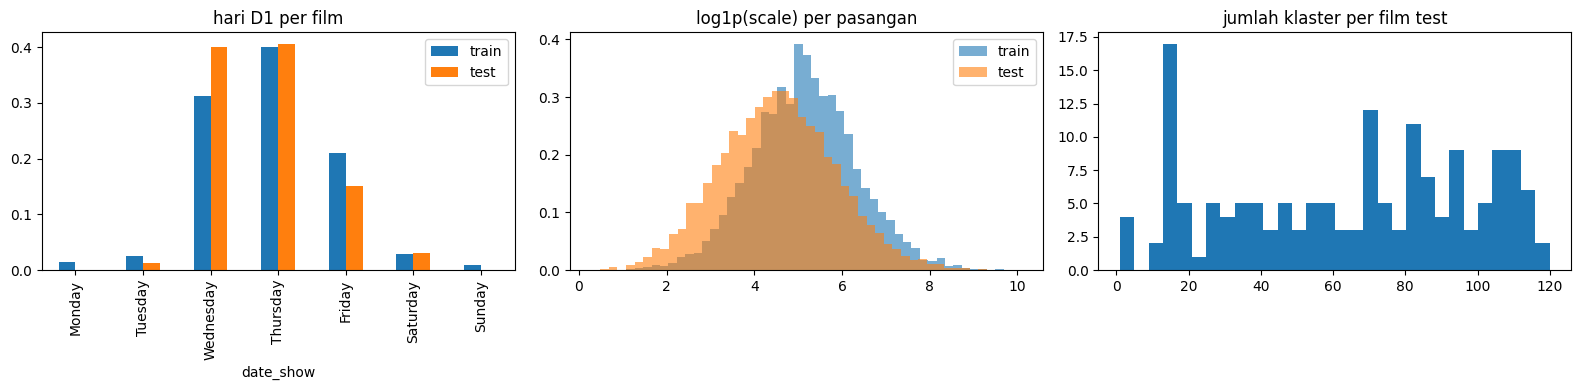

test: 160 film | 10373 pasangan | 72611 baris
baris per pasangan: {7: 10373}


In [13]:
test_d1 = test.groupby("movie_title")["date_show"].min() - pd.Timedelta(days=3)
test_pairs = test[["movie_title", "cinema_ids"]].drop_duplicates()
th = test_hist.merge(test_pairs, on=["movie_title", "cinema_ids"])
test_scale = th.groupby(["movie_title", "cinema_ids"])["total_ticket"].sum() / 3
train_scale = curve[[1, 2, 3]].mean(axis=1)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
pd.DataFrame({
    "train": eda_d1.dt.day_name().value_counts(normalize=True),
    "test": test_d1.dt.day_name().value_counts(normalize=True),
}).reindex(DAY_ORDER).plot(kind="bar", ax=ax[0], title="hari D1 per film")
ax[1].hist(np.log1p(train_scale), bins=50, alpha=0.6, density=True, label="train")
ax[1].hist(np.log1p(test_scale), bins=50, alpha=0.6, density=True, label="test")
ax[1].set_title("log1p(scale) per pasangan")
ax[1].legend()
ax[2].hist(test_pairs.groupby("movie_title").size(), bins=30)
ax[2].set_title("jumlah klaster per film test")
plt.tight_layout()
plt.show()
print(f"test: {test_d1.size} film | {len(test_pairs)} pasangan | {len(test)} baris")
print("baris per pasangan:", test.groupby(["movie_title", "cinema_ids"]).size().value_counts().to_dict())

### Klaster dan kota
Besar kecilnya klaster dan kota berdasarkan rata-rata tiket per film-hari, serta sebaran jumlah klaster per kota.

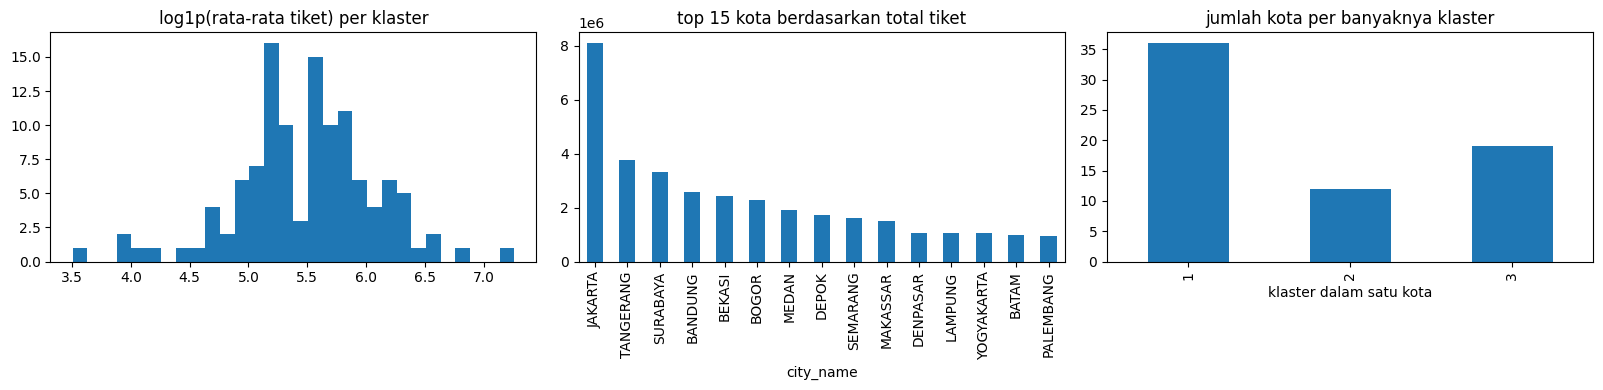

In [14]:
cluster_size = train.groupby("cinema_ids")["total_ticket"].mean()
city_size = train.groupby("city_name")["total_ticket"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log1p(cluster_size), bins=30)
ax[0].set_title("log1p(rata-rata tiket) per klaster")
city_size.head(15).plot(kind="bar", ax=ax[1], title="top 15 kota berdasarkan total tiket")
train.groupby("city_name")["cinema_ids"].nunique().value_counts().sort_index().plot(kind="bar", ax=ax[2], title="jumlah kota per banyaknya klaster", xlabel="klaster dalam satu kota")
plt.tight_layout()
plt.show()

### Harga tiket
Harga tiket per kota untuk setiap tipe hari, dan hubungannya dengan rata-rata tiket kota tersebut.

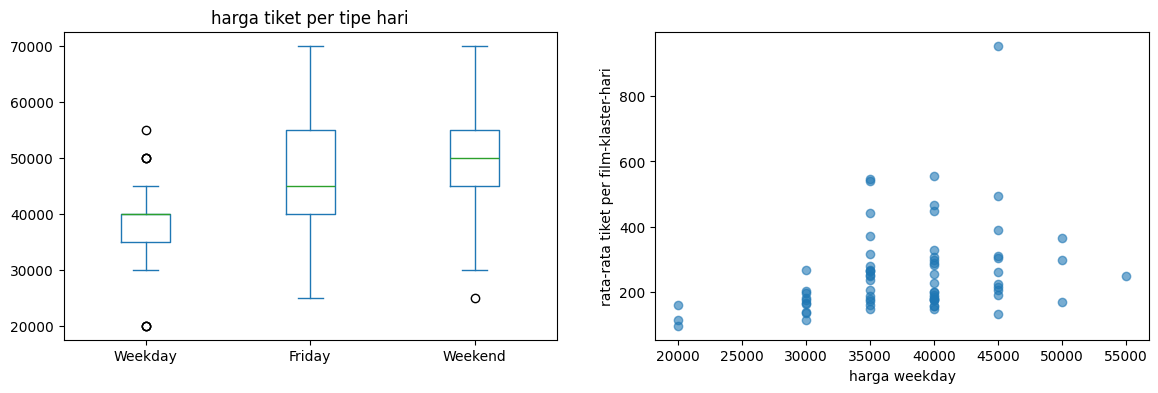

price_day,Friday,Weekday,Weekend
count,69.000000,69.000000,69.000000
mean,47318.840580,37753.623188,50144.927536
std,9057.809035,6781.041472,9154.355059
min,25000.000000,20000.000000,25000.000000
25%,40000.000000,35000.000000,45000.000000
50%,45000.000000,40000.000000,50000.000000
75%,55000.000000,40000.000000,55000.000000
max,70000.000000,55000.000000,70000.000000


In [15]:
price_wide = prices.pivot(index="city_name", columns="price_day", values="ceil")
city_mean = train.groupby("city_name")["total_ticket"].mean()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
price_wide[["Weekday", "Friday", "Weekend"]].plot(kind="box", ax=ax[0], title="harga tiket per tipe hari")
ax[1].scatter(price_wide["Weekday"].reindex(city_mean.index), city_mean, alpha=0.6)
ax[1].set_xlabel("harga weekday")
ax[1].set_ylabel("rata-rata tiket per film-klaster-hari")
plt.show()
price_wide.describe()

### Metadata film
Sebaran age_rating dan genre di movies.csv, lalu median rasio D4-D10 terhadap D1-D3 per genre untuk melihat apakah genre memengaruhi kecepatan penurunan.

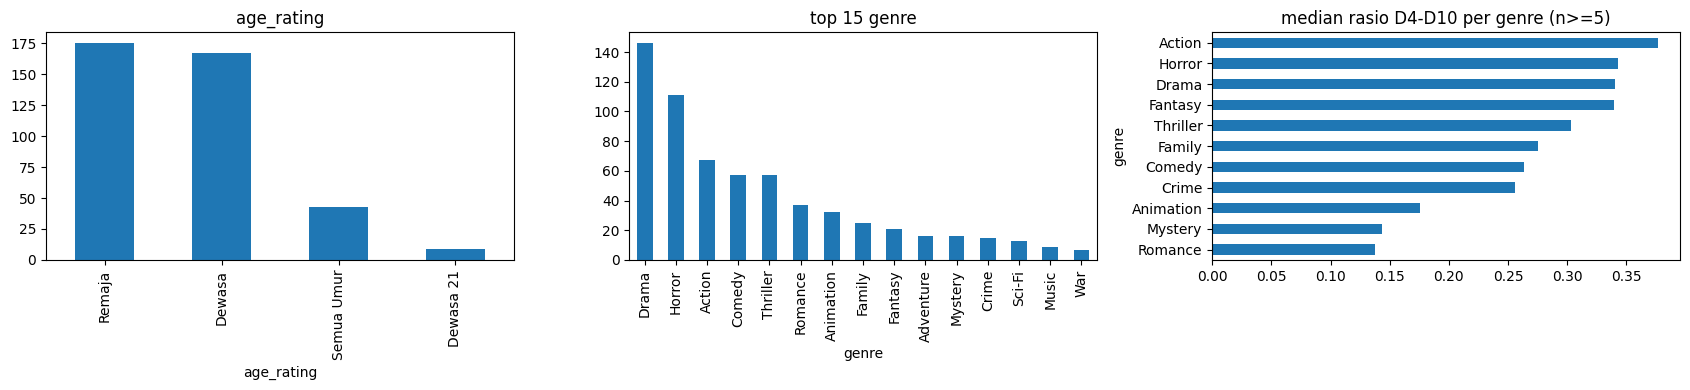

In [16]:
meta = movies.assign(genre=movies["genre"].str.split(", ")).explode("genre")
mv_ratio = ratio[list(range(4, 11))].mean(axis=1).groupby(level="movie_title").median().rename("ratio_d4_d10")
genre_ratio = meta.merge(mv_ratio, left_on="original_title", right_index=True).groupby("genre")["ratio_d4_d10"].agg(["median", "size"])

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
movies["age_rating"].value_counts().plot(kind="bar", ax=ax[0], title="age_rating")
meta["genre"].value_counts().head(15).plot(kind="bar", ax=ax[1], title="top 15 genre")
genre_ratio[genre_ratio["size"] >= 5]["median"].sort_values().plot(kind="barh", ax=ax[2], title="median rasio D4-D10 per genre (n>=5)")
plt.tight_layout()
plt.show()

### Okupansi dan jumlah pertunjukan
Hubungan tiket dengan jumlah pertunjukan dan okupansi, karena keduanya adalah sinyal langsung dari seberapa besar bioskop memberi slot ke film.

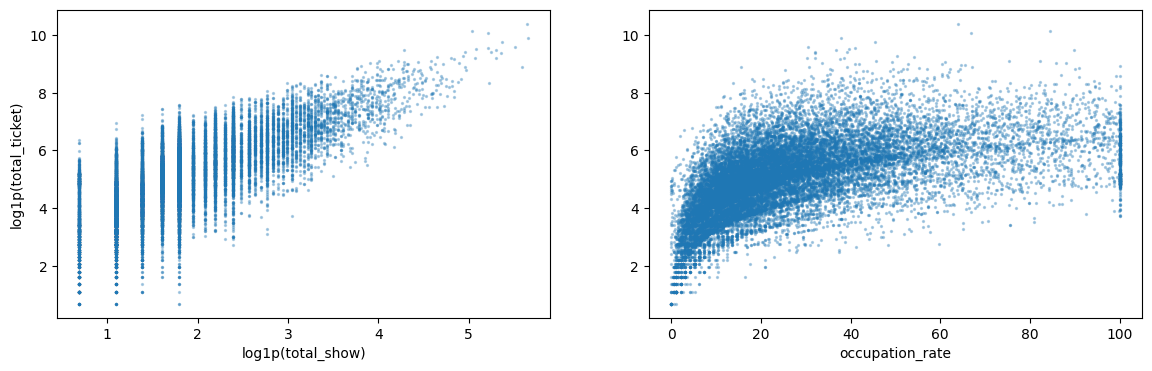

,total_ticket,occupation_rate,total_show
total_ticket,1.000000,0.637488,0.717030
occupation_rate,0.637488,1.000000,0.066615
total_show,0.717030,0.066615,1.000000


In [17]:
sample = train.sample(20000, random_state=42)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].scatter(np.log1p(sample["total_show"]), np.log1p(sample["total_ticket"]), s=2, alpha=0.3)
ax[0].set_xlabel("log1p(total_show)")
ax[0].set_ylabel("log1p(total_ticket)")
ax[1].scatter(sample["occupation_rate"], np.log1p(sample["total_ticket"]), s=2, alpha=0.3)
ax[1].set_xlabel("occupation_rate")
plt.show()
train[["total_ticket", "occupation_rate", "total_show"]].corr(method="spearman")